# Carga del Modelo entrenado

In [ ]:
!wget https://zenodo.org/records/15565400/files/EfficientNetV2S%20Trained%20Model%20Weights.zip

--2025-06-11 14:16:56--  https://zenodo.org/records/15565400/files/EfficientNetV2S%20Trained%20Model%20Weights.zip
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.43.25, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 227385399 (217M) [application/octet-stream]
Saving to: ‘EfficientNetV2S Trained Model Weights.zip’

EfficientNetV2S Tra 100%[===================>] 216.85M  25.3MB/s    in 9.8s    

2025-06-11 14:17:07 (22.1 MB/s) - ‘EfficientNetV2S Trained Model Weights.zip’ saved [227385399/227385399]



In [ ]:
!unzip "/content/EfficientNetV2S Trained Model Weights.zip"

Archive:  /content/EfficientNetV2S Trained Model Weights.zip
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/assets/
 extracting: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/fingerprint.pb  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/keras_metadata.pb  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/saved_model.pb  
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/variables.data-00000-of-00001  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/variables.index  


In [ ]:
!wget https://zenodo.org/records/15565400/files/Replication%20Data.zip

--2025-06-11 14:17:50--  https://zenodo.org/records/15565400/files/Replication%20Data.zip
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.45.92, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 852640867 (813M) [application/octet-stream]
Saving to: ‘Replication Data.zip’

Replication Data.zi 100%[===================>] 813.14M  25.8MB/s    in 3m 59s  

2025-06-11 14:21:50 (3.40 MB/s) - ‘Replication Data.zip’ saved [852640867/852640867]



In [ ]:
!unzip "/content/Replication Data.zip"

Archive:  /content/Replication Data.zip
   creating: Replication Data/
  inflating: Replication Data/ARG_2010_EPHC-S2_v03_M_v06_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2013_EPHC-S2_v03_M_v06_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2018_EPHC-S2_v01_M_v05_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2022_EPHC-S2_v01_M_v01_A_SEDLAC-03_all.dta  
  inflating: Replication Data/censo2010_fullraw_p.dta  
  inflating: Replication Data/deciles_2010.xlsx  
 extracting: Replication Data/income_estimates_2013.cpg  
  inflating: Replication Data/income_estimates_2013.dbf  
  inflating: Replication Data/income_estimates_2013.prj  
  inflating: Replication Data/income_estimates_2013.shp  
  inflating: Replication Data/income_estimates_2013.shx  
 extracting: Replication Data/income_estimates_2018.cpg  
  inflating: Replication Data/income_estimates_2018.dbf  
  inflating: Replication Data/income_estimates_2018.prj  
  inflating: Replication Data/income_estima

In [ ]:
from keras.layers import TFSMLayer

# Ruta al directorio que contiene el modelo, no al archivo `.pb`
model_path = '/content/effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/'

# Cargar el modelo como capa inferencial
layer = TFSMLayer(model_path, call_endpoint='serving_default')

# Nueva imagen

In [ ]:
!pip install earthengine-api --quiet

import ee
ee.Authenticate()
ee.Initialize(project='sanguine-healer-331000')

In [134]:
# Definí el punto de interés
point = ee.Geometry.Point([-58.45, -34.6])

# Buffer de 100m para un parche de 200 × 200 m
aoi_200m = point.buffer(100).bounds()

# Cargar Landsat‑8 (Collection 2, Level 2)
landsat = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
           .filterBounds(point)
           .filterDate('2020-01-01', '2020-12-31')
           .filter(ee.Filter.lt('CLOUD_COVER', 10))
           .first())

# Bandas multiespectrales + pancromática
bands = ['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7','SR_B8']
image = landsat.select(bands).toFloat()

# Exportar con resolución de 30 m/píxel (resolución real de las bandas SR_B*)
task = ee.batch.Export.image.toDrive(
    image=image,
    description='patch_200m_landsat8_with_panchro',
    folder='earthengine',
    fileNamePrefix='patch_200m_landsat8_panchro',
    region=aoi_200m,
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e8
)

task.start()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
img_path = '/content/drive/MyDrive/earthengine/patch_50m_128px_landsat.tif'

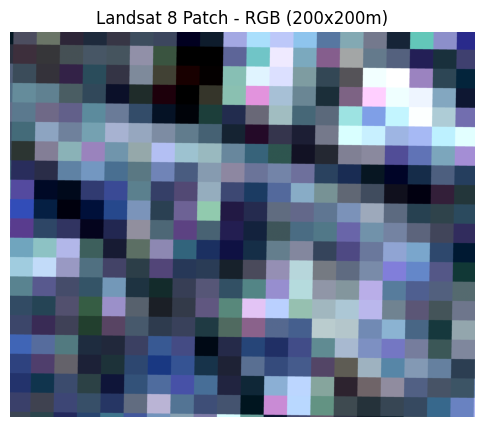

In [127]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

img_path = '/content/drive/MyDrive/earthengine/patch_200m_sentinel2.tif'

with rasterio.open(img_path) as src:
    img = src.read()

# Seleccionar bandas RGB (Bandas 4-3-2 → índices 3,2,1)
r = img[3 - 1].astype(np.float32)
g = img[2 - 1].astype(np.float32)
b = img[1 - 1].astype(np.float32)

# Apilar en eje de color
rgb = np.stack([r, g, b], axis=-1)

# Normalización usando percentiles
p2, p98 = np.percentile(rgb, (2, 98))
rgb_norm = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# Mostrar
plt.figure(figsize=(6,6))
plt.imshow(rgb_norm)
plt.axis('off')
plt.title('Landsat 8 Patch - RGB (200x200m)')
plt.show()


# Inferencia

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 26.5 MB/s eta 0:00:00


In [ ]:
import rasterio
import numpy as np
from skimage.util import view_as_windows
from skimage.transform import resize

# Ruta de la imagen original Landsat 8 con 8 bandas
img_path = '/content/drive/MyDrive/Landsat8_BuenosAires_B1_B8_TOA.tif'

# 1. Cargar imagen de 8 bandas (shape: [8, height, width])
with rasterio.open(img_path) as src:
    img_data = src.read().astype(np.float32)  # (8, H, W)

# Transponer para (H, W, 8)
img_data = np.transpose(img_data, (1, 2, 0))

print(f"Imagen original shape: {img_data.shape}")

# 2. Definir tamaño de parche en píxeles
patch_size = 128

# 3. Crear imagen "grande" remuestreando la original a menor resolución espacial
# Reducimos la imagen por factor 4 en cada dimensión para simular escala mayor (menos detalle espacial)
scale_factor = 0.25  # 1/4

# Calcular nuevo tamaño
new_h = int(img_data.shape[0] * scale_factor)
new_w = int(img_data.shape[1] * scale_factor)

# Remuestrear imagen 8 bandas a nueva resolución espacial (más grande)
img_large = np.zeros((new_h, new_w, 8), dtype=np.float32)
for i in range(8):
    img_large[..., i] = resize(img_data[..., i], (new_h, new_w), anti_aliasing=True)

print(f"Imagen grande remuestreada shape: {img_large.shape}")

# 4. Extraer parches de la imagen original (pequeña)
# Cortamos para que el tamaño sea múltiplo del patch_size para que no haya errores
h_cropped = (img_data.shape[0] // patch_size) * patch_size
w_cropped = (img_data.shape[1] // patch_size) * patch_size
img_small_cropped = img_data[:h_cropped, :w_cropped, :4]  # solo primeras 4 bandas

patches_small = view_as_windows(img_small_cropped, (patch_size, patch_size, 4), step=(patch_size, patch_size, 4))
patches_small = patches_small.reshape(-1, patch_size, patch_size, 4)

print(f"Parches pequeños (4 bandas) shape: {patches_small.shape}")

# 5. Extraer parches de la imagen grande remuestreada
h_large_cropped = (img_large.shape[0] // patch_size) * patch_size
w_large_cropped = (img_large.shape[1] // patch_size) * patch_size
img_large_cropped = img_large[:h_large_cropped, :w_large_cropped, :4]  # solo primeras 4 bandas

patches_large = view_as_windows(img_large_cropped, (patch_size, patch_size, 4), step=(patch_size, patch_size, 4))
patches_large = patches_large.reshape(-1, patch_size, patch_size, 4)

print(f"Parches grandes (4 bandas) shape: {patches_large.shape}")

# 6. Alinear cantidad de parches para evitar desajustes por redondeos (tomamos el mínimo)
n_patches = min(patches_small.shape[0], patches_large.shape[0])
patches_small = patches_small[:n_patches]
patches_large = patches_large[:n_patches]

# 7. Apilar las dos imágenes para obtener patches con 8 bandas
patches_8bands = np.concatenate([patches_small, patches_large], axis=-1)  # shape: (N, 128, 128, 8)

print(f"Parches apilados 8 bandas shape: {patches_8bands.shape}")
print(f"Dtype: {patches_8bands.dtype}")

# Ya tenés patches_8bands listo para pasar al modelo


Imagen original shape: (1123, 934, 8)
Imagen grande remuestreada shape: (280, 233, 8)
Parches pequeños (4 bandas) shape: (56, 128, 128, 4)
Parches grandes (4 bandas) shape: (2, 128, 128, 4)
Parches apilados 8 bandas shape: (2, 128, 128, 8)
Dtype: float32


In [ ]:
import numpy as np
import rasterio
from skimage.transform import resize
import tensorflow as tf

# 1. Cargar imagen original (8 bandas)
img_path = '/content/drive/MyDrive/Landsat8_BuenosAires_B1_B8_TOA.tif'
with rasterio.open(img_path) as src:
    img = src.read().transpose(1, 2, 0).astype(np.float32)  # shape: (H, W, 8)

print(f"Imagen original shape: {img.shape}")

# 2. Remuestrear (factor 4 para que sea más manejable)
factor = 4
img_resized = resize(img, (img.shape[0] // factor, img.shape[1] // factor), preserve_range=True, anti_aliasing=True).astype(np.float32)
print(f"Imagen remuestreada shape: {img_resized.shape}")

# 3. Seleccionar un parche central de 128x128x8
H, W, _ = img_resized.shape
start_y = (H - 128) // 2
start_x = (W - 128) // 2
parche = img_resized[start_y:start_y + 128, start_x:start_x + 128, :]  # shape: (128, 128, 8)

# 4. Asegurar que no haya NaNs
parche = np.nan_to_num(parche, nan=0.0)

# 5. Inferencia
input_tensor = tf.convert_to_tensor(parche[np.newaxis, ...], dtype=tf.float32)  # shape: (1, 128, 128, 8)
raw_output = layer(input_tensor, training=False)

# 6. Obtener predicción
if isinstance(raw_output, dict):
    preds = raw_output[list(raw_output.keys())[0]].numpy().squeeze()
else:
    preds = raw_output.numpy().squeeze()

print(f"Predicción del modelo: {preds:.4f}")

Imagen original shape: (1123, 934, 8)
Imagen remuestreada shape: (280, 233, 8)
Predicción del modelo: -1.0265
